# MGF Prediction with Transformer

This notebook tests the transformer's ability to predict the log conditional moment-generating function φ(s | X_L, θ) from OU trajectories.

In [38]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.model import SimpleTransformer
from src.mgf_dataset import compute_log_mgf_targets

## 1. Load Configuration and Data

In [39]:
cfg = load_full_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load data
data_path = os.path.join('..', cfg['paths']['mgf_data_path'])
data = torch.load(data_path, weights_only=False)

trajectories = data['trajectories']
targets = data['targets']
theta_values = data['theta_values']
s_range = data['s_range']

print(f"Loaded {len(trajectories)} trajectories")
print(f"Trajectory shape: {trajectories.shape}")
print(f"Target shape: {targets.shape}")
print(f"Theta range: [{theta_values.min():.3f}, {theta_values.max():.3f}]")
print(f"S range: [{s_range.min():.2f}, {s_range.max():.2f}] with {len(s_range)} points")

Loaded 10000 trajectories
Trajectory shape: torch.Size([10000, 100, 1])
Target shape: torch.Size([10000, 50])
Theta range: [0.178, 6.754]
S range: [-2.00, 2.00] with 50 points


## 2. Load Trained Model

In [40]:
model = SimpleTransformer(**cfg['architecture'])
model_path = os.path.join('..', cfg['paths']['save_dir'], 'model_mgf.pth')

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.to(device)
    model.eval()
    print(f"Loaded model from {model_path}")
else:
    print(f"Model not found at {model_path}")
    print("Run: python ../scripts/train.py")

Loaded model from ../experiments/model_mgf.pth


## 3. Test on Sample Trajectories

In [41]:
# Select test samples
num_test = 10
test_indices = np.random.choice(len(trajectories), num_test, replace=False)

test_trajectories = trajectories[test_indices]
test_targets = targets[test_indices]
test_thetas = theta_values[test_indices]

# Get predictions
with torch.no_grad():
    preds, _ = model(test_trajectories.to(device))
    predictions = preds[:, -1, :].cpu()  # Last timestep predictions

# Compute errors
errors = (predictions - test_targets).abs()
mean_error = errors.mean(dim=1)

print("Test Results:")
print(f"Mean absolute error per trajectory: {mean_error.mean():.6f} ± {mean_error.std():.6f}")
print(f"Max error: {errors.max():.6f}")

Test Results:
Mean absolute error per trajectory: 0.004980 ± 0.005122
Max error: 0.036788


## 4. Visualize Predictions

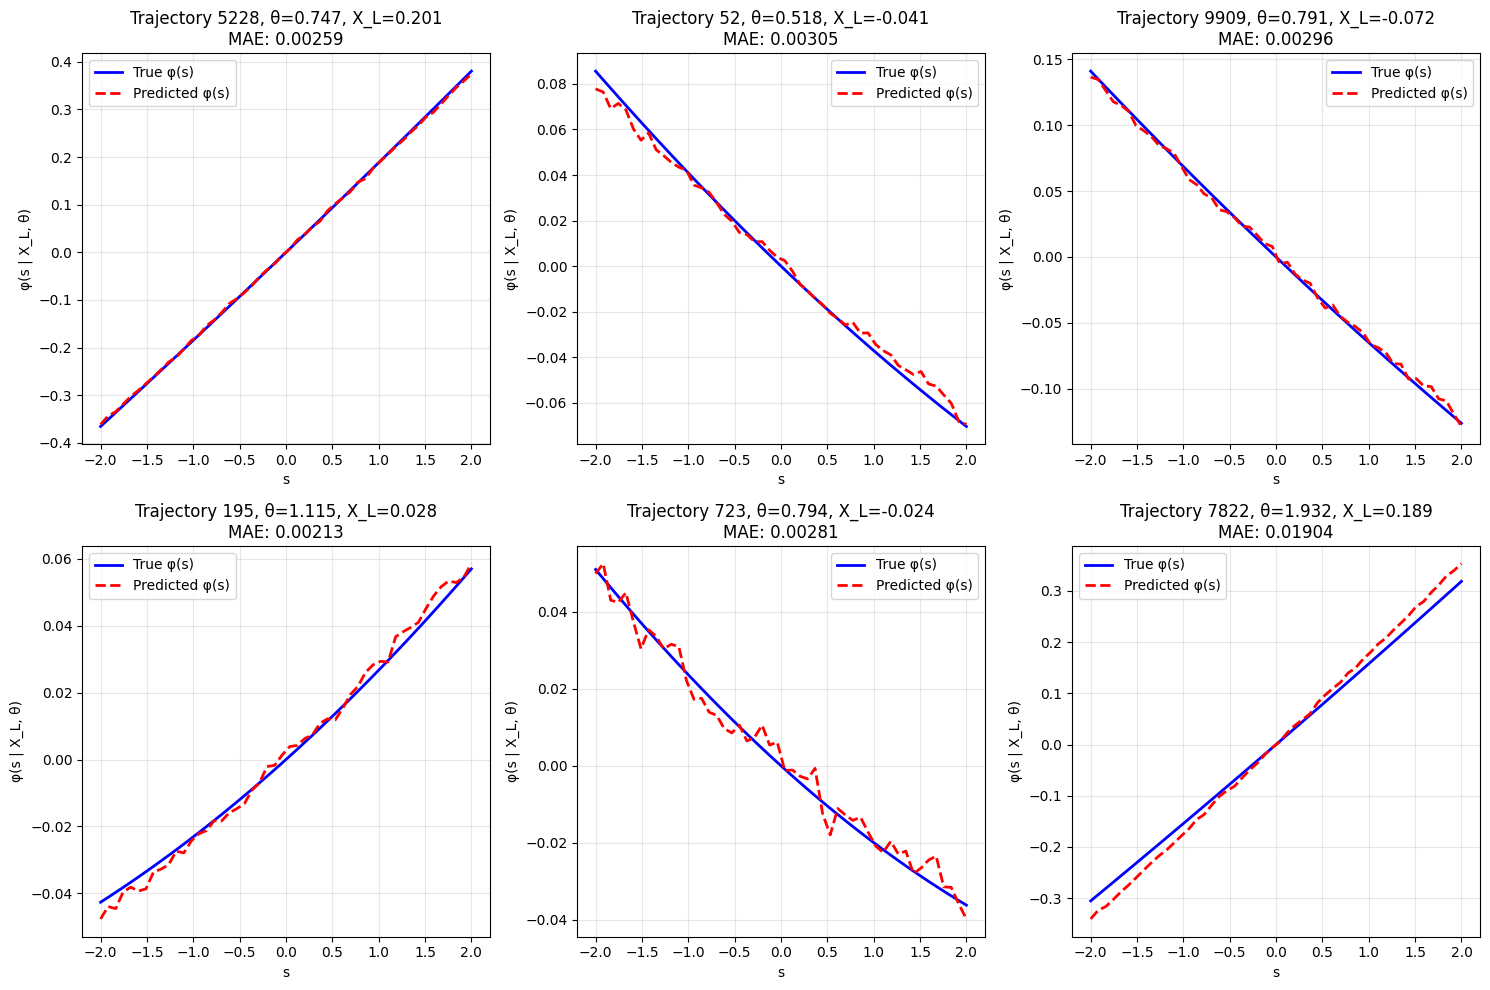

In [42]:
# Plot a few examples
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(min(6, num_test)):
    ax = axes[i]
    
    X_L = test_trajectories[i, -1, 0].item()  # Extract last state value
    
    ax.plot(s_range, test_targets[i].numpy(), 'b-', label='True φ(s)', linewidth=2)
    ax.plot(s_range, predictions[i].numpy(), 'r--', label='Predicted φ(s)', linewidth=2)
    ax.set_xlabel('s')
    ax.set_ylabel('φ(s | X_L, θ)')
    ax.set_title(f'Trajectory {test_indices[i]}, θ={test_thetas[i]:.3f}, X_L={X_L:.3f}\nMAE: {mean_error[i]:.5f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Analyze Prediction Error vs Gamma

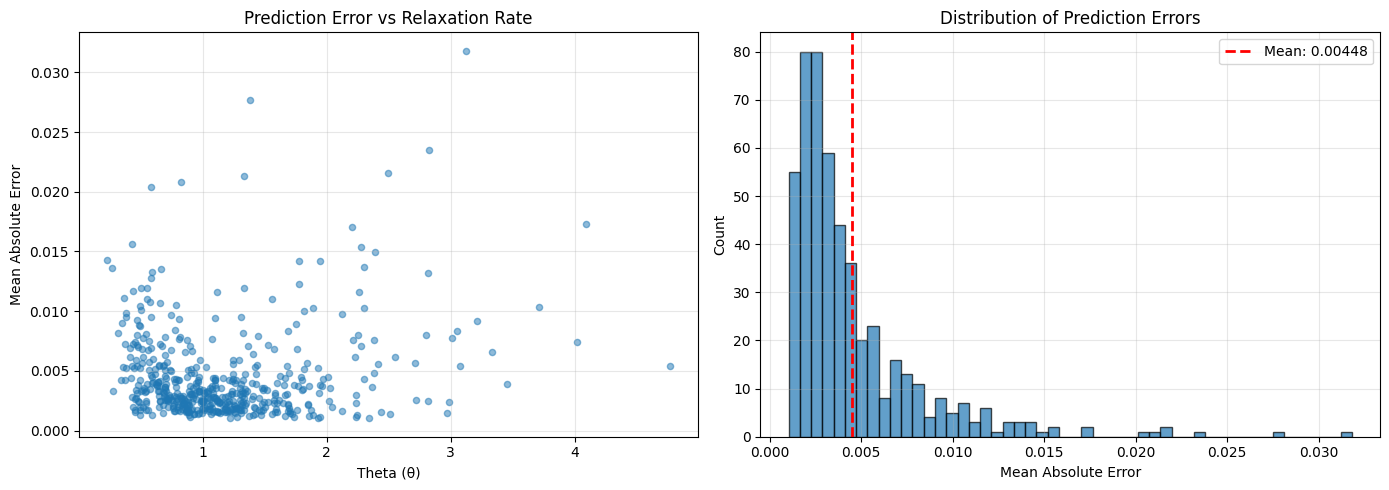


Error statistics:
  Mean: 0.004475
  Median: 0.003237
  Std: 0.003812
  Min: 0.001022
  Max: 0.031816


In [43]:
# Test on more samples
num_test_large = 500
test_indices_large = np.random.choice(len(trajectories), num_test_large, replace=False)

test_trajectories_large = trajectories[test_indices_large]
test_targets_large = targets[test_indices_large]
test_thetas_large = theta_values[test_indices_large]

with torch.no_grad():
    preds_large, _ = model(test_trajectories_large.to(device))
    predictions_large = preds_large[:, -1, :].cpu()

errors_large = (predictions_large - test_targets_large).abs().mean(dim=1)

# Plot error vs theta
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax = axes[0]
ax.scatter(test_thetas_large.numpy(), errors_large.numpy(), alpha=0.5, s=20)
ax.set_xlabel('Theta (θ)')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('Prediction Error vs Relaxation Rate')
ax.grid(True, alpha=0.3)

# Histogram of errors
ax = axes[1]
ax.hist(errors_large.numpy(), bins=50, alpha=0.7, edgecolor='black')
ax.axvline(x=errors_large.mean().item(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {errors_large.mean():.5f}')
ax.set_xlabel('Mean Absolute Error')
ax.set_ylabel('Count')
ax.set_title('Distribution of Prediction Errors')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nError statistics:")
print(f"  Mean: {errors_large.mean():.6f}")
print(f"  Median: {errors_large.median():.6f}")
print(f"  Std: {errors_large.std():.6f}")
print(f"  Min: {errors_large.min():.6f}")
print(f"  Max: {errors_large.max():.6f}")

## 6. Visualize Sample Trajectory

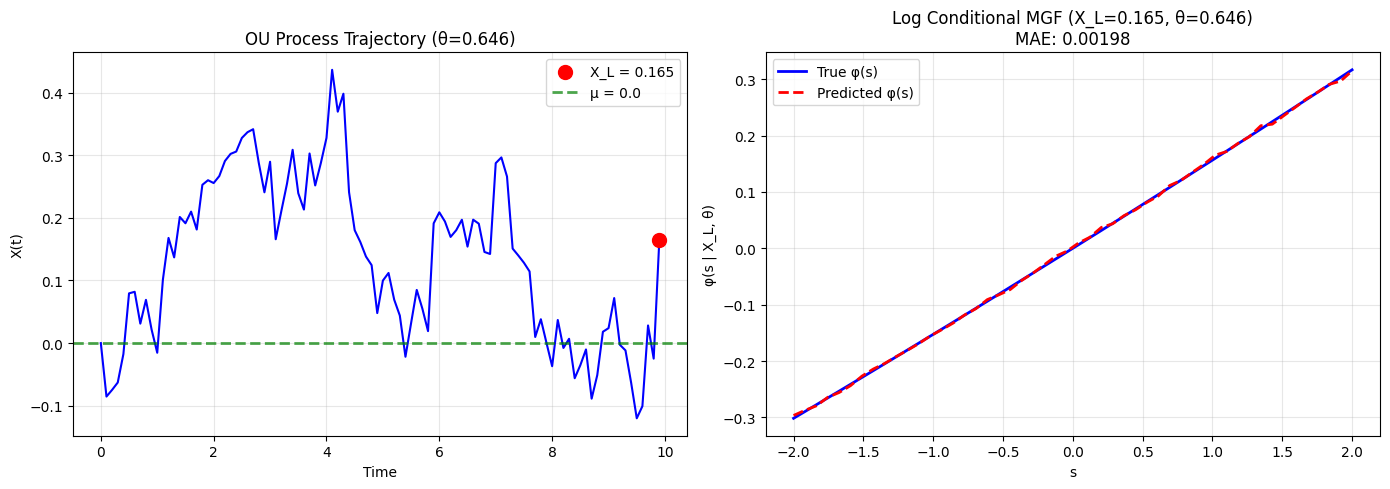

In [44]:
# Pick one trajectory to visualize
idx = 0
traj = test_trajectories_large[idx].squeeze().numpy()
theta_val = test_thetas_large[idx].item()
X_L = traj[-1]

timestamps = np.arange(len(traj)) * cfg['physics']['dt']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot trajectory
ax = axes[0]
ax.plot(timestamps, traj, 'b-', linewidth=1.5)
ax.scatter([timestamps[-1]], [X_L], color='red', s=100, zorder=5, label=f'X_L = {X_L:.3f}')
ax.axhline(y=cfg['physics']['mu'], color='green', linestyle='--', 
           linewidth=2, alpha=0.7, label=f"μ = {cfg['physics']['mu']}")
ax.set_xlabel('Time')
ax.set_ylabel('X(t)')
ax.set_title(f'OU Process Trajectory (θ={theta_val:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot MGF
ax = axes[1]
ax.plot(s_range, test_targets_large[idx].numpy(), 'b-', label='True φ(s)', linewidth=2)
ax.plot(s_range, predictions_large[idx].numpy(), 'r--', label='Predicted φ(s)', linewidth=2)
ax.set_xlabel('s')
ax.set_ylabel('φ(s | X_L, θ)')
ax.set_title(f'Log Conditional MGF (X_L={X_L:.3f}, θ={theta_val:.3f})\nMAE: {errors_large[idx]:.5f}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Extract Mean and Variance via Parabolic Fitting

The log MGF has the form: φ(s) = s·μ + 0.5·s²·σ² = As² + Bs

From the fitted coefficients:
- **Predicted Mean**: μ = B (linear coefficient)
- **Predicted Variance**: σ² = 2A (twice the quadratic coefficient)

Note: There is no constant term since φ(0) = 0.

In [45]:
from scipy.optimize import curve_fit

def parabola(s, A, B):
    """Quadratic function: φ(s) = As² + Bs (no constant term)"""
    return A * s**2 + B * s

def extract_moments_from_mgf(mgf_predictions, s_range):
    """
    Extract mean and variance from MGF predictions via parabolic fitting.
    
    Args:
        mgf_predictions: Shape (batch_size, seq_len, num_s) or (seq_len, num_s)
        s_range: Array of s values
    
    Returns:
        means: Predicted means (same shape as input minus last dim)
        variances: Predicted variances (same shape as input minus last dim)
        coeffs: Fitted coefficients (A, B) for each timestep
    """
    if mgf_predictions.ndim == 2:
        # Single trajectory: (seq_len, num_s)
        seq_len, num_s = mgf_predictions.shape
        means = np.zeros(seq_len)
        variances = np.zeros(seq_len)
        coeffs = np.zeros((seq_len, 2))
        
        for t in range(seq_len):
            phi_values = mgf_predictions[t, :]
            # Fit parabola (no constant term)
            popt, _ = curve_fit(parabola, s_range, phi_values)
            A, B = popt
            coeffs[t] = [A, B]
            means[t] = B
            variances[t] = 2 * A
            
    elif mgf_predictions.ndim == 3:
        # Batch of trajectories: (batch_size, seq_len, num_s)
        batch_size, seq_len, num_s = mgf_predictions.shape
        means = np.zeros((batch_size, seq_len))
        variances = np.zeros((batch_size, seq_len))
        coeffs = np.zeros((batch_size, seq_len, 2))
        
        for b in range(batch_size):
            for t in range(seq_len):
                phi_values = mgf_predictions[b, t, :]
                # Fit parabola (no constant term)
                popt, _ = curve_fit(parabola, s_range, phi_values)
                A, B = popt
                coeffs[b, t] = [A, B]
                means[b, t] = B
                variances[b, t] = 2 * A
    else:
        raise ValueError(f"Expected 2D or 3D input, got shape {mgf_predictions.shape}")
    
    return means, variances, coeffs

print("Functions defined successfully!")

Functions defined successfully!


In [46]:
# Select a test trajectory to analyze in detail
test_idx = 0
test_traj = test_trajectories[test_idx:test_idx+1].to(device)  # (1, seq_len, 1)
test_theta = test_thetas[test_idx].item()

# Get model prediction at the LAST timestep only (as the model was trained)
with torch.no_grad():
    preds, _ = model(test_traj)  # (1, seq_len, num_s)
    phi_pred = preds[0, -1, :].cpu().numpy()  # Take only last timestep (num_s,)

# Extract the trajectory
traj = test_traj[0].cpu().numpy().squeeze()  # (seq_len,)
X_L = traj[-1]

# Fit parabola to extract moments
popt, _ = curve_fit(parabola, s_range, phi_pred)
A, B = popt

# Extract mean and variance (single values!)
predicted_mean = B
predicted_variance = 2 * A

# Compute theoretical values
theta = test_theta
D = cfg['physics']['D']
dt = cfg['physics']['dt']
mu_long_term = cfg['physics']['mu']

# Theoretical conditional mean: E[X_{t+1} | X_t] = e^(-θ dt) X_t + μ(1 - e^(-θ dt))
exp_theta_dt = np.exp(-theta * dt)
theoretical_mean = exp_theta_dt * X_L + mu_long_term * (1 - exp_theta_dt)

# Theoretical conditional variance: Var[X_{t+1} | X_t] = (D/θ)(1 - e^(-2θ dt))
theoretical_variance = (D / theta) * (1 - np.exp(-2 * theta * dt))

print(f"Test Trajectory {test_idx}: θ={theta:.3f}, X_L={X_L:.3f}")
print(f"\n{'='*60}")
print("MOMENT EXTRACTION FROM MGF")
print(f"{'='*60}")
print(f"\nFitted Parabola: φ(s) = {A:.6f}s² + {B:.4f}s")
print(f"\nExtracted Mean (B):")
print(f"  Predicted:    {predicted_mean:.4f}")
print(f"  Theoretical:  {theoretical_mean:.4f}")
print(f"  Error:        {abs(predicted_mean - theoretical_mean):.6f}")
print(f"\nExtracted Variance (2A):")
print(f"  Predicted:    {predicted_variance:.6f}")
print(f"  Theoretical:  {theoretical_variance:.6f}")
print(f"  Rel. Error:   {abs(predicted_variance - theoretical_variance) / theoretical_variance * 100:.2f}%")
print(f"{'='*60}")

Test Trajectory 0: θ=0.747, X_L=0.201

MOMENT EXTRACTION FROM MGF

Fitted Parabola: φ(s) = 0.001699s² + 0.1844s

Extracted Mean (B):
  Predicted:    0.1844
  Theoretical:  0.1865
  Error:        0.002017

Extracted Variance (2A):
  Predicted:    0.003397
  Theoretical:  0.003716
  Rel. Error:   8.57%


In [47]:
# Analyze multiple trajectories: extract moments and compare to ground truth
num_test = 100
test_indices = np.random.choice(len(trajectories), num_test, replace=False)

test_trajs = trajectories[test_indices].to(device)
test_thetas_batch = theta_values[test_indices]

# Get predictions for all test trajectories
with torch.no_grad():
    preds, _ = model(test_trajs)
    phi_preds = preds[:, -1, :].cpu().numpy()  # (num_test, num_s)

# Extract trajectories and last states
trajs = test_trajs.cpu().numpy().squeeze()  # (num_test, seq_len)
X_Ls = trajs[:, -1]  # (num_test,)

# Initialize arrays for predicted and theoretical moments
predicted_means = np.zeros(num_test)
predicted_variances = np.zeros(num_test)
theoretical_means = np.zeros(num_test)
theoretical_variances = np.zeros(num_test)

# Extract moments for each trajectory
for i in range(num_test):
    # Fit parabola to extract predicted moments
    popt, _ = curve_fit(parabola, s_range, phi_preds[i])
    A, B = popt
    predicted_means[i] = B
    predicted_variances[i] = 2 * A
    
    # Compute theoretical moments
    theta_i = test_thetas_batch[i].item()
    X_L_i = X_Ls[i]
    
    exp_theta_dt = np.exp(-theta_i * dt)
    theoretical_means[i] = exp_theta_dt * X_L_i + mu_long_term * (1 - exp_theta_dt)
    theoretical_variances[i] = (D / theta_i) * (1 - np.exp(-2 * theta_i * dt))

print(f"Processed {num_test} trajectories")
print(f"\nMean Statistics:")
print(f"  R² = {np.corrcoef(theoretical_means, predicted_means)[0,1]**2:.4f}")
print(f"  Mean Absolute Error: {np.abs(predicted_means - theoretical_means).mean():.6f}")
print(f"\nVariance Statistics:")
print(f"  R² = {np.corrcoef(theoretical_variances, predicted_variances)[0,1]**2:.4f}")
print(f"  Mean Absolute Error: {np.abs(predicted_variances - theoretical_variances).mean():.6f}")
print(f"  Mean Relative Error: {(np.abs(predicted_variances - theoretical_variances) / theoretical_variances).mean() * 100:.2f}%")

Processed 100 trajectories

Mean Statistics:
  R² = 0.9984
  Mean Absolute Error: 0.003947

Variance Statistics:
  R² = 0.0004
  Mean Absolute Error: 0.000238
  Mean Relative Error: 6.68%


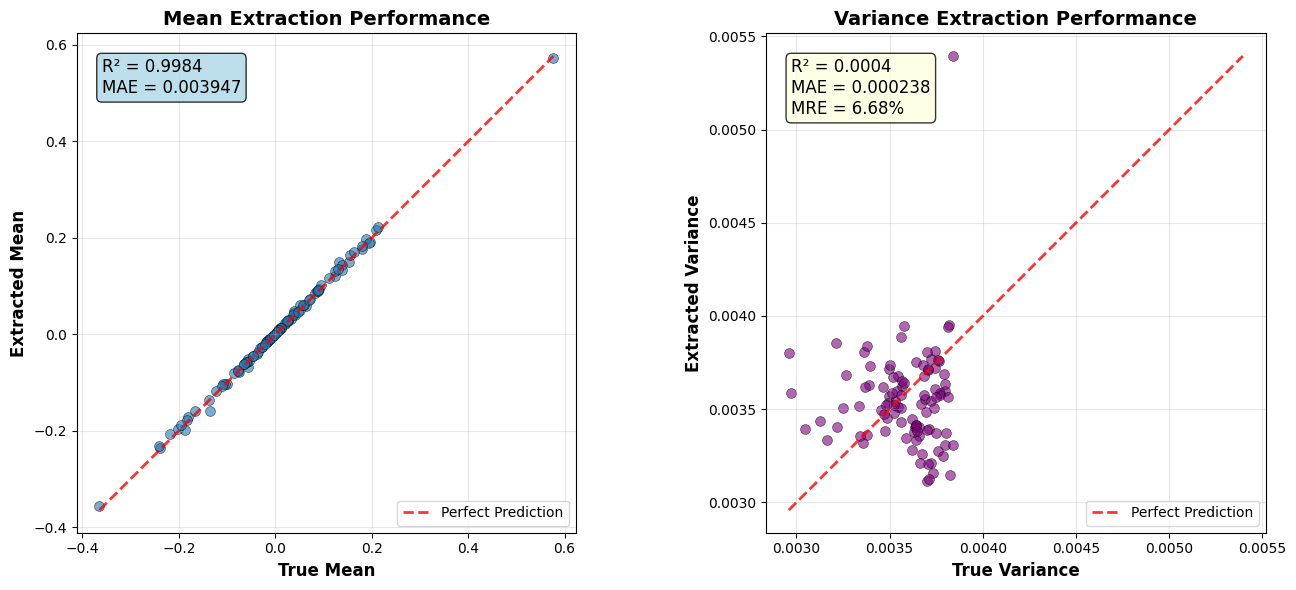

In [48]:
# Create comparison plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left Panel: Mean Comparison ---
ax = axes[0]
ax.scatter(theoretical_means, predicted_means, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

# Add diagonal line (perfect prediction)
min_val = min(theoretical_means.min(), predicted_means.min())
max_val = max(theoretical_means.max(), predicted_means.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction', alpha=0.8)

# Calculate R² and add to plot
r2_mean = np.corrcoef(theoretical_means, predicted_means)[0,1]**2
mae_mean = np.abs(predicted_means - theoretical_means).mean()

ax.text(0.05, 0.95, f'R² = {r2_mean:.4f}\nMAE = {mae_mean:.6f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

ax.set_xlabel('True Mean', fontsize=12, fontweight='bold')
ax.set_ylabel('Extracted Mean', fontsize=12, fontweight='bold')
ax.set_title('Mean Extraction Performance', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')

# --- Right Panel: Variance Comparison ---
ax = axes[1]
ax.scatter(theoretical_variances, predicted_variances, alpha=0.6, s=50, 
           edgecolors='black', linewidth=0.5, color='purple')

# Add diagonal line (perfect prediction)
min_val = min(theoretical_variances.min(), predicted_variances.min())
max_val = max(theoretical_variances.max(), predicted_variances.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction', alpha=0.8)

# Calculate R² and add to plot
r2_var = np.corrcoef(theoretical_variances, predicted_variances)[0,1]**2
mae_var = np.abs(predicted_variances - theoretical_variances).mean()
mre_var = (np.abs(predicted_variances - theoretical_variances) / theoretical_variances).mean() * 100

ax.text(0.05, 0.95, f'R² = {r2_var:.4f}\nMAE = {mae_var:.6f}\nMRE = {mre_var:.2f}%', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.set_xlabel('True Variance', fontsize=12, fontweight='bold')
ax.set_ylabel('Extracted Variance', fontsize=12, fontweight='bold')
ax.set_title('Variance Extraction Performance', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()